UCI Diabetes Dataset Sample:
   Glucose  BloodPressure  SkinThickness  Insulin        BMI  \
0      193             72             25      169  23.722020   
1      200            107             40       48  39.019181   
2      165             59             26      165  38.047034   
3      152            101             10      300  44.676570   
4      171             85             27      108  29.709714   

   DiabetesPedigreeFunction  Age  Outcome  
0                  0.287041   42        0  
1                  1.276820   26        0  
2                  1.303484   37        0  
3                  0.370960   25        0  
4                  0.520054   39        0  

Pima Indians Diabetes Dataset Sample:
   Glucose  BloodPressure  SkinThickness  Insulin        BMI  \
0      145             67             39       39  45.000000   
1      101             75             12       15  29.082089   
2      147             87             50       84  32.060206   
3       80             66  

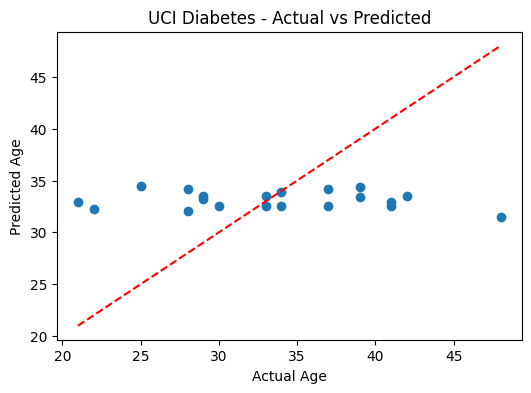

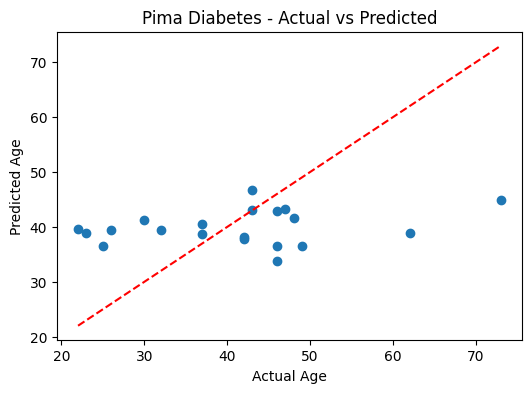

In [37]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Load the Datasets
uci_diabetes = pd.read_csv('/content/uci_diabetes.csv')
pima_diabetes = pd.read_csv('/content/pima_diabetes.csv')

# Display Dataset Samples
print("UCI Diabetes Dataset Sample:")
print(uci_diabetes.head())

print("\nPima Indians Diabetes Dataset Sample:")
print(pima_diabetes.head())

# Select Features and Target Variable
features = ["Glucose", "BloodPressure", "BMI"]
target = "Age"

X_uci = uci_diabetes[features]
y_uci = uci_diabetes[target]

X_pima = pima_diabetes[features]
y_pima = pima_diabetes[target]

# Split Data into Training and Testing Sets
X_train_uci, X_test_uci, y_train_uci, y_test_uci = train_test_split(
    X_uci, y_uci, test_size=0.2, random_state=42
)

X_train_pima, X_test_pima, y_train_pima, y_test_pima = train_test_split(
    X_pima, y_pima, test_size=0.2, random_state=42
)

# Train Linear Regression Models
model_uci = LinearRegression()
model_uci.fit(X_train_uci, y_train_uci)

model_pima = LinearRegression()
model_pima.fit(X_train_pima, y_train_pima)

# Predictions
y_pred_uci = model_uci.predict(X_test_uci)
y_pred_pima = model_pima.predict(X_test_pima)

# Evaluation Metrics
r2_uci = r2_score(y_test_uci, y_pred_uci)
mse_uci = mean_squared_error(y_test_uci, y_pred_uci)
mae_uci = mean_absolute_error(y_test_uci, y_pred_uci)

r2_pima = r2_score(y_test_pima, y_pred_pima)
mse_pima = mean_squared_error(y_test_pima, y_pred_pima)
mae_pima = mean_absolute_error(y_test_pima, y_pred_pima)

# Display Results
print("\nUCI Diabetes Dataset - Linear Regression Results")
print("R2 Score :", round(r2_uci,4))
print("MSE      :", round(mse_uci,4))
print("MAE      :", round(mae_uci,4))

print("\nPima Indians Diabetes Dataset - Linear Regression Results")
print("R2 Score :", round(r2_pima,4))
print("MSE      :", round(mse_pima,4))
print("MAE      :", round(mae_pima,4))

# Plot - UCI Dataset
plt.figure(figsize=(6,4))
plt.scatter(y_test_uci, y_pred_uci)
plt.plot(
    [y_test_uci.min(), y_test_uci.max()],
    [y_test_uci.min(), y_test_uci.max()],
    'r--'
)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("UCI Diabetes - Actual vs Predicted")
plt.show()

# Plot - Pima Dataset
plt.figure(figsize=(6,4))
plt.scatter(y_test_pima, y_pred_pima)
plt.plot(
    [y_test_pima.min(), y_test_pima.max()],
    [y_test_pima.min(), y_test_pima.max()],
    'r--'
)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Pima Diabetes - Actual vs Predicted")
plt.show()